In [2]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("../../data/processed/X_train.csv")
X_test = pd.read_csv("../../data/processed/X_test.csv")

y_train = pd.read_csv("../../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24000, 34)
X_test : (6000, 34)
y_train: (24000,)
y_test : (6000,)


In [3]:
print(X_train.dtypes)

appeared_year               float64
appeared_month              float64
hist_mean                   float64
hist_std                    float64
hist_min                    float64
hist_max                    float64
hist_sum                    float64
entropy_mean                float64
entropy_std                 float64
entropy_min                 float64
entropy_max                 float64
strings_numstrings          float64
strings_avlength            float64
strings_printables          float64
strings_entropy             float64
strings_paths               float64
strings_urls                float64
strings_registry            float64
strings_MZ                  float64
general_size                float64
general_vsize               float64
general_has_debug           float64
general_exports             float64
general_imports             float64
general_has_relocations     float64
general_has_resources       float64
general_has_signature       float64
general_has_tls             

In [4]:
print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude=np.number).columns.tolist())


Non-numeric columns:
[]


In [5]:
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [6]:
lgbm_baseline = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_baseline.fit(X_train, y_train)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [7]:
y_pred_lgbm = lgbm_baseline.predict(X_test)

lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_precision = precision_score(y_test, y_pred_lgbm)
lgbm_recall = recall_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm)

print("LightGBM Baseline")
print("-----------------")
print("Accuracy :", round(lgbm_accuracy, 4))
print("Precision:", round(lgbm_precision, 4))
print("Recall   :", round(lgbm_recall, 4))
print("F1 Score :", round(lgbm_f1, 4))

LightGBM Baseline
-----------------
Accuracy : 0.9152
Precision: 0.9294
Recall   : 0.9086
F1 Score : 0.9189


In [8]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Baseline",
        "LightGBM - Baseline"
    ],
    "Accuracy": [
        0.9350,
        lgbm_accuracy
    ],
    "Precision": [
        0.9624,
        lgbm_precision
    ],
    "Recall": [
        0.9127,
        lgbm_recall
    ],
    "F1 Score": [
        0.9369,
        lgbm_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest - Baseline,0.935000,0.962400,0.912700,0.936900
1,LightGBM - Baseline,0.915167,0.929378,0.908575,0.918859


In [9]:
comparison_display = comparison.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).round(2).astype(str) + "%"

comparison_display

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest - Baseline,93.5%,96.24%,91.27%,93.69%
1,LightGBM - Baseline,91.52%,92.94%,90.86%,91.89%


In [10]:
import joblib

final_model = joblib.load(
    "../../models/random_forest_baseline.pkl"
)

print("Baseline Random Forest loaded successfully.")

Baseline Random Forest loaded successfully.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)

                     Feature  Importance
30             imports_count    0.067051
12          strings_avlength    0.059533
31  total_imported_functions    0.053076
14           strings_entropy    0.052127
4                   hist_min    0.051831
23           general_imports    0.049555
10               entropy_max    0.047401
20             general_vsize    0.046691
27           general_has_tls    0.046005
18                strings_MZ    0.043169
8                entropy_std    0.042834
16              strings_urls    0.040770
3                   hist_std    0.038192
13        strings_printables    0.036330
5                   hist_max    0.034897
11        strings_numstrings    0.034758
19              general_size    0.031318
6                   hist_sum    0.030592
2                  hist_mean    0.029371
7               entropy_mean    0.028060
21         general_has_debug    0.025715
29    section_sections_count    0.025242
15             strings_paths    0.022671
26     general_h

In [12]:
top_features = rf_importance.head(15)

print(top_features)

                     Feature  Importance
30             imports_count    0.067051
12          strings_avlength    0.059533
31  total_imported_functions    0.053076
14           strings_entropy    0.052127
4                   hist_min    0.051831
23           general_imports    0.049555
10               entropy_max    0.047401
20             general_vsize    0.046691
27           general_has_tls    0.046005
18                strings_MZ    0.043169
8                entropy_std    0.042834
16              strings_urls    0.040770
3                   hist_std    0.038192
13        strings_printables    0.036330
5                   hist_max    0.034897


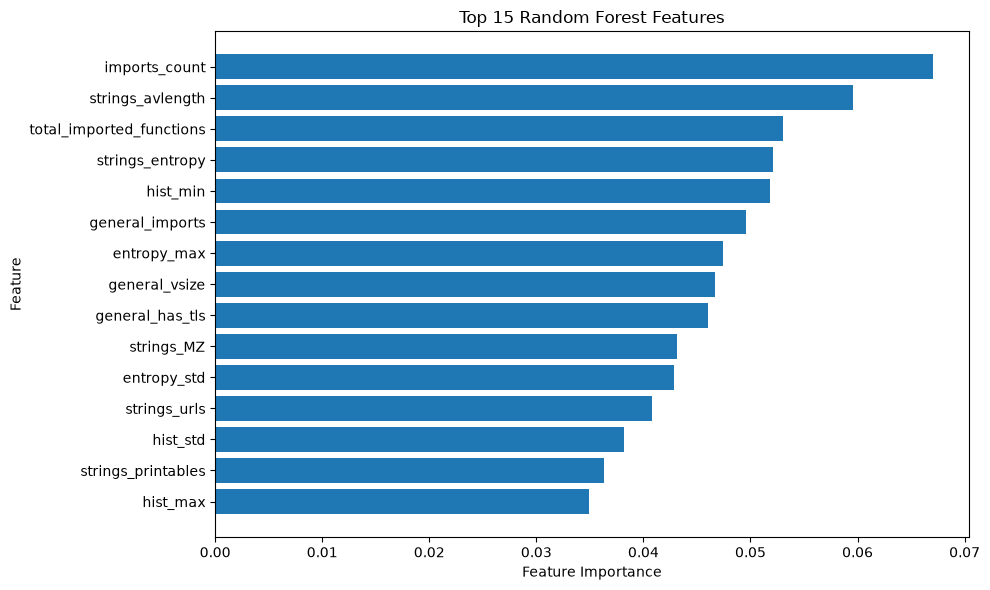

In [13]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.tight_layout()
plt.show()

In [14]:
feature_sets = {
    "All 34 Features": rf_importance["Feature"].tolist(),
    "Top 25 Features": rf_importance.head(25)["Feature"].tolist(),
    "Top 20 Features": rf_importance.head(20)["Feature"].tolist(),
    "Top 15 Features": rf_importance.head(15)["Feature"].tolist()
}

for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")

All 34 Features: 34 features
Top 25 Features: 25 features
Top 20 Features: 20 features
Top 15 Features: 15 features


In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nNumber of features in importance table:",
      len(rf_importance))

print("\nFeatures missing from X_train:")
print(set(rf_importance["Feature"]) - set(X_train.columns))

X_train shape: (24000, 34)
X_test shape : (6000, 34)

Number of features in importance table: 34

Features missing from X_train:
set()


In [16]:
feature_sets = {
    "All 34 Features": rf_importance["Feature"].tolist(),
    "Top 25 Features": rf_importance.head(25)["Feature"].tolist(),
    "Top 20 Features": rf_importance.head(20)["Feature"].tolist(),
    "Top 15 Features": rf_importance.head(15)["Feature"].tolist()
}

for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")

All 34 Features: 34 features
Top 25 Features: 25 features
Top 20 Features: 20 features
Top 15 Features: 15 features


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

feature_results = []

for name, features in feature_sets.items():

    print(f"\nTraining: {name}")

    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_subset, y_train)

    y_pred = model.predict(X_test_subset)

    feature_results.append({
        "Feature Set": name,
        "Number of Features": len(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

    print(
        f"Accuracy: {feature_results[-1]['Accuracy']:.4f} | "
        f"Precision: {feature_results[-1]['Precision']:.4f} | "
        f"Recall: {feature_results[-1]['Recall']:.4f} | "
        f"F1: {feature_results[-1]['F1 Score']:.4f}"
    )


Training: All 34 Features
Accuracy: 0.9343 | Precision: 0.9572 | Recall: 0.9168 | F1: 0.9366

Training: Top 25 Features
Accuracy: 0.9353 | Precision: 0.9567 | Recall: 0.9193 | F1: 0.9376

Training: Top 20 Features
Accuracy: 0.9282 | Precision: 0.9555 | Recall: 0.9064 | F1: 0.9303

Training: Top 15 Features
Accuracy: 0.9292 | Precision: 0.9550 | Recall: 0.9089 | F1: 0.9314


In [18]:
feature_comparison = pd.DataFrame(feature_results)

feature_comparison = feature_comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

feature_comparison

,Feature Set,Number of Features,Accuracy,Precision,Recall,F1 Score
0,Top 25 Features,25,0.935333,0.956693,0.919294,0.937621
1,All 34 Features,34,0.934333,0.957209,0.916772,0.936554
2,Top 15 Features,15,0.929167,0.954952,0.908890,0.931352
3,Top 20 Features,20,0.928167,0.955467,0.906368,0.930270


In [19]:
feature_display = feature_comparison.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    feature_display[col] = (
        feature_display[col] * 100
    ).round(2).astype(str) + "%"

feature_display

,Feature Set,Number of Features,Accuracy,Precision,Recall,F1 Score
0,Top 25 Features,25,93.53%,95.67%,91.93%,93.76%
1,All 34 Features,34,93.43%,95.72%,91.68%,93.66%
2,Top 15 Features,15,92.92%,95.5%,90.89%,93.14%
3,Top 20 Features,20,92.82%,95.55%,90.64%,93.03%


In [20]:
top25_features = rf_importance.head(25)["Feature"].tolist()

X_train_top25 = X_train[top25_features]
X_test_top25 = X_test[top25_features]

rf_top25 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_top25.fit(X_train_top25, y_train)

y_pred_top25 = rf_top25.predict(X_test_top25)

In [21]:
from sklearn.metrics import classification_report

print("Random Forest - Top 25 Features")
print("--------------------------------")
print(classification_report(y_test, y_pred_top25))

Random Forest - Top 25 Features
--------------------------------
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2828
           1       0.96      0.92      0.94      3172

    accuracy                           0.94      6000
   macro avg       0.93      0.94      0.94      6000
weighted avg       0.94      0.94      0.94      6000



Confusion Matrix:
[[2696  132]
 [ 256 2916]]


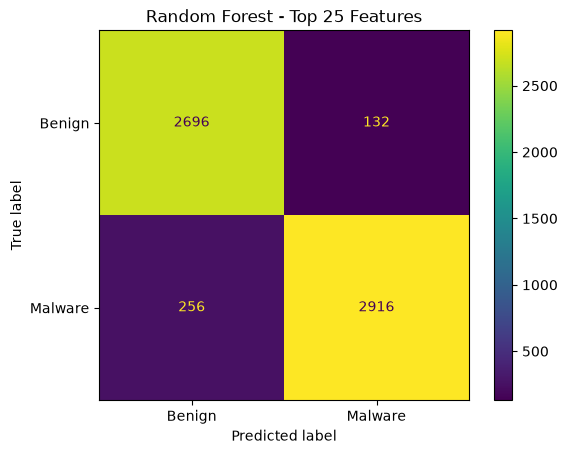

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_top25)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malware"]
).plot()

plt.title("Random Forest - Top 25 Features")
plt.show()

In [23]:
rf_top25.predict_proba(X_test_top25)

array([[0.  , 1.  ],
       [0.  , 1.  ],
       [0.12, 0.88],
       ...,
       [0.98, 0.02],
       [0.59, 0.41],
       [0.  , 1.  ]], shape=(6000, 2))

In [24]:
print(cm)

[[2696  132]
 [ 256 2916]]


In [25]:
# Get probability predictions
y_proba_top25 = rf_top25.predict_proba(X_test_top25)

print("Probability matrix shape:", y_proba_top25.shape)

# First 10 predictions
print("\nFirst 10 probability predictions:")
print(y_proba_top25[:10])

Probability matrix shape: (6000, 2)

First 10 probability predictions:
[[0.   1.  ]
 [0.   1.  ]
 [0.12 0.88]
 [0.77 0.23]
 [1.   0.  ]
 [0.72 0.28]
 [0.74 0.26]
 [0.87 0.13]
 [0.   1.  ]
 [0.   1.  ]]


In [26]:
malware_probability = y_proba_top25[:, 1]

print("Minimum probability:", malware_probability.min())
print("Maximum probability:", malware_probability.max())
print("Mean probability   :", round(malware_probability.mean(), 4))
print("Median probability :", round(np.median(malware_probability), 4))

Minimum probability: 0.0
Maximum probability: 1.0
Mean probability   : 0.534
Median probability : 0.54


In [27]:
probability_bins = pd.cut(
    malware_probability,
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5,
          0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True
)

probability_distribution = (
    probability_bins
    .value_counts()
    .sort_index()
)

print(probability_distribution)

(-0.001, 0.1]    1722
(0.1, 0.2]        501
(0.2, 0.3]        309
(0.3, 0.4]        242
(0.4, 0.5]        178
(0.5, 0.6]        172
(0.6, 0.7]        145
(0.7, 0.8]        147
(0.8, 0.9]        179
(0.9, 1.0]       2405
Name: count, dtype: int64


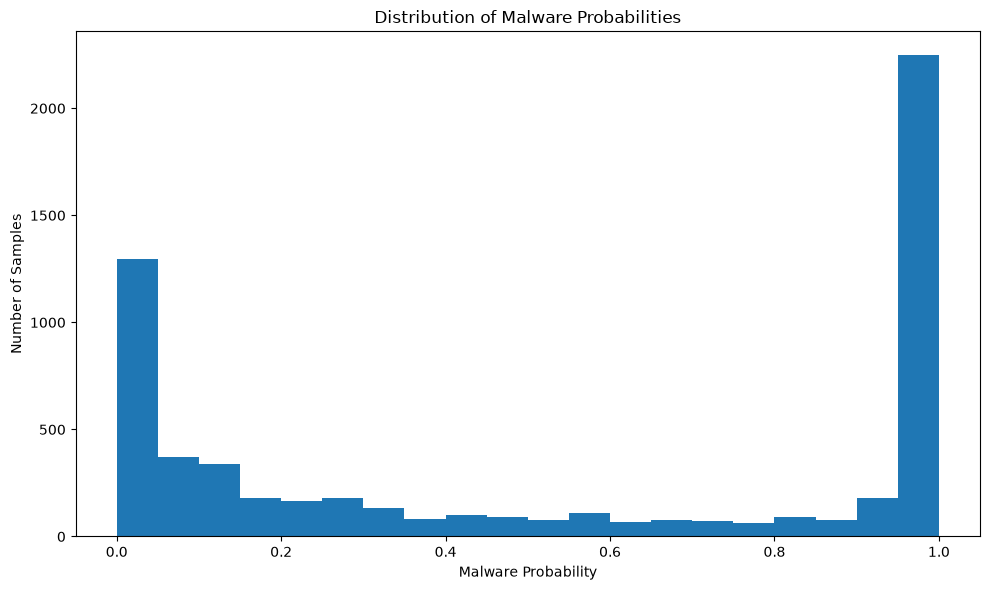

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(
    malware_probability,
    bins=20
)

plt.xlabel("Malware Probability")
plt.ylabel("Number of Samples")
plt.title("Distribution of Malware Probabilities")

plt.tight_layout()
plt.show()

In [29]:
probability_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Malware_Probability": malware_probability
})

probability_analysis["Probability_Bin"] = pd.cut(
    probability_analysis["Malware_Probability"],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5,
          0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True
)

calibration_summary = (
    probability_analysis
    .groupby("Probability_Bin", observed=True)
    .agg(
        Samples=("Actual", "size"),
        Actual_Malware_Rate=("Actual", "mean"),
        Average_Predicted_Probability=("Malware_Probability", "mean")
    )
    .reset_index()
)

calibration_summary["Actual_Malware_Rate"] = (
    calibration_summary["Actual_Malware_Rate"] * 100
).round(2)

calibration_summary["Average_Predicted_Probability"] = (
    calibration_summary["Average_Predicted_Probability"] * 100
).round(2)

calibration_summary

,Probability_Bin,Samples,Actual_Malware_Rate,Average_Predicted_Probability
0,"(-0.001, 0.1]",1722,0.99,2.45
1,"(0.1, 0.2]",501,7.78,15.07
2,"(0.2, 0.3]",309,17.48,25.32
3,"(0.3, 0.4]",242,27.69,35.31
4,"(0.4, 0.5]",178,44.38,45.32
5,"(0.5, 0.6]",172,65.12,55.80
6,"(0.6, 0.7]",145,71.72,64.89
7,"(0.7, 0.8]",147,84.35,75.18
8,"(0.8, 0.9]",179,96.09,85.94
9,"(0.9, 1.0]",2405,99.96,99.28


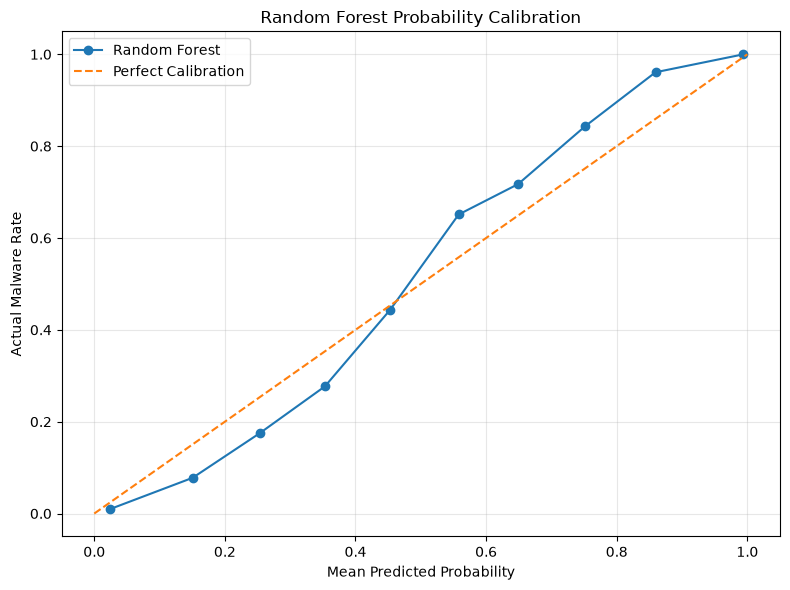

In [30]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    malware_probability,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Malware Rate")
plt.title("Random Forest Probability Calibration")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Get malware probabilities
malware_probability = final_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.05):
    y_pred_threshold = (malware_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives
0,0.10,0.798000,0.724977,0.995586,0.839001,1198,14
1,0.15,0.847500,0.781492,0.987705,0.872580,876,39
2,0.20,0.876167,0.820026,0.981084,0.893354,683,60
3,0.25,0.893500,0.847653,0.973518,0.906236,555,84
4,0.30,0.911000,0.877937,0.965952,0.919844,426,108
5,0.35,0.923000,0.903995,0.955864,0.929206,322,140
6,0.40,0.930167,0.925502,0.943884,0.934603,241,178
7,0.45,0.935667,0.944764,0.932850,0.938769,173,213
8,0.50,0.934833,0.956351,0.918663,0.937128,133,258
9,0.55,0.931500,0.967174,0.901009,0.932920,97,314


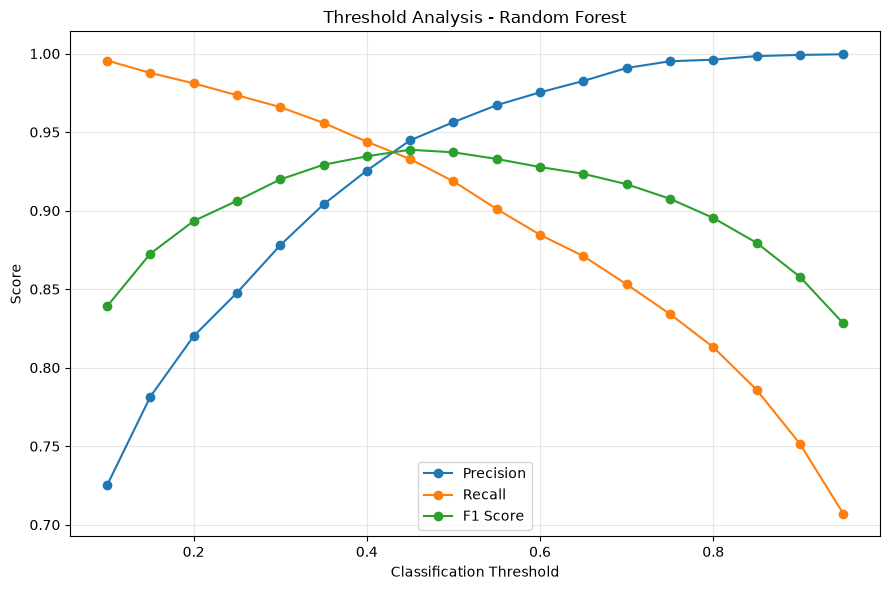

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold            0.450000
Accuracy             0.935667
Precision            0.944764
Recall               0.932850
F1                   0.938769
False Positives    173.000000
False Negatives    213.000000
Name: 7, dtype: float64

In [35]:
# Final classification threshold
FINAL_THRESHOLD = 0.45

# Generate final predictions using the selected threshold
y_pred_final = (malware_probability >= FINAL_THRESHOLD).astype(int)

print("Final Classification Threshold:", FINAL_THRESHOLD)

Final Classification Threshold: 0.45


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

print("Final Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Benign", "Malware"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93      2828
     Malware       0.94      0.94      0.94      3172

    accuracy                           0.94      6000
   macro avg       0.93      0.94      0.93      6000
weighted avg       0.94      0.94      0.94      6000

Confusion Matrix:
[[2644  184]
 [ 205 2967]]


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print(f"Final Accuracy : {final_accuracy:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final Recall   : {final_recall:.4f}")
print(f"Final F1 Score : {final_f1:.4f}")

Final Accuracy : 0.9352
Final Precision: 0.9416
Final Recall   : 0.9354
Final F1 Score : 0.9385


In [38]:
def get_risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.70:
        return "Medium"
    else:
        return "High"

In [39]:
risk_levels = [
    get_risk_level(probability)
    for probability in malware_probability
]

risk_levels[:20]

['High',
 'High',
 'High',
 'Low',
 'Low',
 'Medium',
 'Medium',
 'Low',
 'High',
 'High',
 'Low',
 'High',
 'Low',
 'High',
 'Low',
 'High',
 'Low',
 'Low',
 'High',
 'High']

In [40]:
risk_summary = pd.DataFrame({
    "Malware Probability": malware_probability,
    "Actual Class": y_test.values,
    "Predicted Class": y_pred_final,
    "Risk Level": risk_levels
})

risk_summary.head(10)

,Malware Probability,Actual Class,Predicted Class,Risk Level
0,1.00,1,1,High
1,1.00,1,1,High
2,0.86,1,1,High
3,0.17,0,0,Low
4,0.00,0,0,Low
5,0.31,0,0,Medium
6,0.32,1,0,Medium
7,0.27,0,0,Low
8,1.00,1,1,High
9,1.00,1,1,High


In [41]:
risk_summary["Risk Level"].value_counts()

Risk Level
High      2744
Low       2482
Medium     774
Name: count, dtype: int64

In [42]:
risk_summary["Risk Level"].value_counts(normalize=True).mul(100).round(2)

Risk Level
High      45.73
Low       41.37
Medium    12.90
Name: proportion, dtype: float64

In [43]:
risk_analysis = (
    risk_summary
    .groupby("Risk Level")
    .agg(
        Samples=("Risk Level", "size"),
        Average_Probability=("Malware Probability", "mean"),
        Actual_Malware_Rate=("Actual Class", "mean")
    )
    .reset_index()
)

risk_analysis["Actual_Malware_Rate"] *= 100

risk_analysis

,Risk Level,Samples,Average_Probability,Actual_Malware_Rate
0,High,2744,0.969421,98.943149
1,Low,2482,0.074738,4.270749
2,Medium,774,0.469961,45.348837


In [44]:
def predict_malware_risk(model, features):
    """
    Predict malware probability, classification, and risk level.
    """

    probability = model.predict_proba(features)[0, 1]

    # Final classification threshold
    if probability >= 0.45:
        prediction = "Malware"
    else:
        prediction = "Benign"

    # Risk level
    if probability < 0.30:
        risk_level = "Low"
    elif probability < 0.70:
        risk_level = "Medium"
    else:
        risk_level = "High"

    return {
        "malware_probability": probability,
        "prediction": prediction,
        "risk_level": risk_level
    }

In [47]:
import pandas as pd

# Create feature importance table from the current model
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display the top 25 features
top_25_features = importance_df.head(25)["Feature"].tolist()

print("Number of features:", len(top_25_features))
print(top_25_features)

Number of features: 25
['imports_count', 'strings_avlength', 'total_imported_functions', 'strings_entropy', 'hist_min', 'general_imports', 'entropy_max', 'general_vsize', 'general_has_tls', 'strings_MZ', 'entropy_std', 'strings_urls', 'hist_std', 'strings_printables', 'hist_max', 'strings_numstrings', 'general_size', 'hist_sum', 'hist_mean', 'entropy_mean', 'general_has_debug', 'section_sections_count', 'strings_paths', 'general_has_signature', 'general_exports']


In [48]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=250,
    max_features="log2",
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train[top_25_features],
    y_train
)

print("Final model trained successfully.")

Final model trained successfully.


In [49]:
print("Training features:", len(top_25_features))
print("Model input features:", final_model.n_features_in_)

Training features: 25
Model input features: 25


In [50]:
import joblib
import os

model_path = "../../models/final_malware_rf.pkl"

os.makedirs("../../models", exist_ok=True)

joblib.dump(final_model, model_path)

print("Model saved to:", model_path)

Model saved to: ../../models/final_malware_rf.pkl


In [51]:
features_path = "../../models/final_features.pkl"

joblib.dump(top_25_features, features_path)

print("Feature list saved to:", features_path)

Feature list saved to: ../../models/final_features.pkl


In [52]:
import joblib
import os

model_path = "../../models/final_malware_rf.pkl"

os.makedirs("../../models", exist_ok=True)

joblib.dump(final_model, model_path)

print("Model saved to:", model_path)

Model saved to: ../../models/final_malware_rf.pkl


In [53]:
import os

print("Model exists:", os.path.exists("../../models/final_malware_rf.pkl"))
print("Features exist:", os.path.exists("../../models/final_features.pkl"))

Model exists: True
Features exist: True


In [54]:
import joblib

# Load saved model
loaded_model = joblib.load("../../models/final_malware_rf.pkl")

# Load saved feature list
loaded_features = joblib.load("../../models/final_features.pkl")

print("Model loaded successfully.")
print("Number of features:", len(loaded_features))
print("Model expects:", loaded_model.n_features_in_, "features")

Model loaded successfully.
Number of features: 25
Model expects: 25 features


In [55]:
# Take one test sample
sample = X_test[loaded_features].iloc[[0]]

# Get malware probability
probability = loaded_model.predict_proba(sample)[0, 1]

# Classification using final threshold
prediction = "Malware" if probability >= 0.45 else "Benign"

# Risk level
if probability < 0.30:
    risk_level = "Low"
elif probability < 0.70:
    risk_level = "Medium"
else:
    risk_level = "High"

print(f"Malware Probability: {probability:.4f}")
print(f"Prediction: {prediction}")
print(f"Risk Level: {risk_level}")

Malware Probability: 1.0000
Prediction: Malware
Risk Level: High


In [56]:
def predict_from_features(features, model, feature_list):
    """
    Predict malware status and risk level from extracted PE features.
    """

    # Keep only the features required by the final model
    input_data = features[feature_list]

    # Malware probability
    probability = model.predict_proba(input_data)[0, 1]

    # Final classification threshold
    prediction = "Malware" if probability >= 0.45 else "Benign"

    # Risk level
    if probability < 0.30:
        risk_level = "Low"
    elif probability < 0.70:
        risk_level = "Medium"
    else:
        risk_level = "High"

    return {
        "malware_probability": round(float(probability), 4),
        "prediction": prediction,
        "risk_level": risk_level
    }

In [57]:
sample = X_test[loaded_features].iloc[[0]]

result = predict_from_features(
    sample,
    loaded_model,
    loaded_features
)

result

{'malware_probability': 1.0, 'prediction': 'Malware', 'risk_level': 'High'}

In [59]:
import json

file_path = "../../data/raw/ember2018/train_features_0.jsonl"

with open(file_path, "r", encoding="utf-8") as f:
    first_record = json.loads(f.readline())

print(first_record.keys())

dict_keys(['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories'])


In [5]:
import json

file_path = "../../data/raw/ember2018/train_features_0.jsonl"

with open(file_path, "r", encoding="utf-8") as f:
    for i in range(5):
        record = json.loads(f.readline())
        
        print("Label:", repr(record.get("label")),
              "Type:", type(record.get("label")))
        print("AVClass:", repr(record.get("avclass")))
        print("-" * 50)

Label: 0 Type: <class 'int'>
AVClass: ''
--------------------------------------------------
Label: 0 Type: <class 'int'>
AVClass: ''
--------------------------------------------------
Label: 0 Type: <class 'int'>
AVClass: ''
--------------------------------------------------
Label: 0 Type: <class 'int'>
AVClass: ''
--------------------------------------------------
Label: 0 Type: <class 'int'>
AVClass: ''
--------------------------------------------------


In [7]:
import json
from collections import Counter

file_path = "../../data/raw/ember2018/train_features_0.jsonl"

labels = Counter()

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        labels[repr(record.get("label"))] += 1

print(labels)

Counter({'0': 50000})


In [9]:
import json
from collections import Counter

base_path = "../../data/raw/ember2018"

for i in range(6):
    file_path = f"{base_path}/train_features_{i}.jsonl"

    labels = Counter()
    avclass_count = 0

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line)

            labels[repr(record.get("label"))] += 1

            if record.get("avclass"):
                avclass_count += 1

    print(f"\ntrain_features_{i}.jsonl")
    print("Labels:", labels)
    print("Records with avclass:", avclass_count)


train_features_0.jsonl
Labels: Counter({'0': 50000})
Records with avclass: 0

train_features_1.jsonl
Labels: Counter({'1': 63713, '0': 52338, '-1': 42107})
Records with avclass: 80217

train_features_2.jsonl
Labels: Counter({'1': 47044, '0': 46563, '-1': 34284})
Records with avclass: 60258

train_features_3.jsonl
Labels: Counter({'1': 47309, '0': 47004, '-1': 34882})
Records with avclass: 60735

train_features_4.jsonl
Labels: Counter({'0': 48433, '1': 48413, '-1': 35336})
Records with avclass: 61760

train_features_5.jsonl
Labels: Counter({'1': 93521, '0': 55662, '-1': 53391})
Records with avclass: 122709


In [11]:
import json
from collections import Counter

base_path = "../../data/raw/ember2018"

family_counts = Counter()

for i in range(1, 6):
    file_path = f"{base_path}/train_features_{i}.jsonl"

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line)

            # Only labelled malware
            if record.get("label") == 1:
                family = record.get("avclass")

                if family:
                    family = str(family).strip()

                    if family:
                        family_counts[family] += 1

print("Total malware samples with AVClass:", sum(family_counts.values()))
print("Unique malware families:", len(family_counts))

print("\nTop 30 malware families:")
for family, count in family_counts.most_common(30):
    print(f"{family}: {count}")

Total malware samples with AVClass: 289246
Unique malware families: 2731

Top 30 malware families:
xtrat: 16689
installmonster: 16356
zusy: 13951
vtflooder: 12118
zbot: 10782
ramnit: 10275
fareit: 10274
sality: 9522
adposhel: 8570
emotet: 8039
high: 7706
sivis: 4377
flystudio: 4351
wapomi: 4236
startsurf: 3993
dealply: 3934
upatre: 3901
bladabindi: 3669
razy: 3223
filetour: 3199
gandcrab: 2878
wannacry: 2810
lethic: 2810
gamarue: 2556
virlock: 2525
vittalia: 2518
ursnif: 2455
prepscram: 2237
downloadguide: 2093
installcore: 1863


In [12]:
TOP_FAMILIES = [
    family for family, count in family_counts.most_common(20)
]

print("Selected families:")
for i, family in enumerate(TOP_FAMILIES, 1):
    print(f"{i}. {family}")

Selected families:
1. xtrat
2. installmonster
3. zusy
4. vtflooder
5. zbot
6. ramnit
7. fareit
8. sality
9. adposhel
10. emotet
11. high
12. sivis
13. flystudio
14. wapomi
15. startsurf
16. dealply
17. upatre
18. bladabindi
19. razy
20. filetour


In [13]:
import json
import pandas as pd

base_path = "../../data/raw/ember2018"

family_records = []

for i in range(1, 6):
    file_path = f"{base_path}/train_features_{i}.jsonl"

    print(f"Processing train_features_{i}.jsonl...")

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line)

            # Only labelled malware
            if record.get("label") != 1:
                continue

            family = record.get("avclass")

            # Keep only selected families
            if family not in TOP_FAMILIES:
                continue

            family_records.append(record)

print("\nTotal selected samples:", len(family_records))

Processing train_features_1.jsonl...
Processing train_features_2.jsonl...
Processing train_features_3.jsonl...
Processing train_features_4.jsonl...
Processing train_features_5.jsonl...

Total selected samples: 159165


In [14]:
sample = family_records[0]

print("Family:", sample["avclass"])
print("Label:", sample["label"])

print("\nTop-level feature structures:")
for key in [
    "histogram",
    "byteentropy",
    "strings",
    "general",
    "header",
    "section",
    "imports",
    "exports",
    "datadirectories"
]:
    value = sample.get(key)

    if isinstance(value, dict):
        print(f"{key}: dict with {len(value)} fields")
    elif isinstance(value, list):
        print(f"{key}: list with {len(value)} values")
    else:
        print(f"{key}: {type(value).__name__}")

Family: sivis
Label: 1

Top-level feature structures:
histogram: list with 256 values
byteentropy: list with 256 values
strings: dict with 9 fields
general: dict with 10 fields
header: dict with 2 fields
section: dict with 2 fields
imports: dict with 6 fields
exports: list with 0 values
datadirectories: list with 15 values


In [15]:
import joblib
import pandas as pd
import numpy as np

# Load the exact 25 features used by the final malware detector
feature_list = joblib.load("../../models/final_features.pkl")

print("Number of features:", len(feature_list))
print("\nFeatures:")
print(feature_list)

Number of features: 25

Features:
['imports_count', 'strings_avlength', 'total_imported_functions', 'strings_entropy', 'hist_min', 'general_imports', 'entropy_max', 'general_vsize', 'general_has_tls', 'strings_MZ', 'entropy_std', 'strings_urls', 'hist_std', 'strings_printables', 'hist_max', 'strings_numstrings', 'general_size', 'hist_sum', 'hist_mean', 'entropy_mean', 'general_has_debug', 'section_sections_count', 'strings_paths', 'general_has_signature', 'general_exports']


In [22]:
import numpy as np
import pandas as pd


def extract_family_features(record):
    """
    Extract the 25 features used by the final malware detector
    from an EMBER 2018 record.
    """

    general = record.get("general", {})
    strings = record.get("strings", {})
    imports = record.get("imports", {})
    section = record.get("section", {})

    histogram = np.asarray(
        record.get("histogram", []),
        dtype=float
    )

    byteentropy = np.asarray(
        record.get("byteentropy", []),
        dtype=float
    )

    features = {
        # Imports
        "imports_count": len(imports),
        "total_imported_functions": sum(
            len(functions)
            for functions in imports.values()
            if isinstance(functions, list)
        ),

        # Strings
        "strings_avlength": strings.get("avlength", 0),
        "strings_entropy": strings.get("entropy", 0),
        "strings_MZ": strings.get("MZ", 0),
        "strings_urls": strings.get("urls", 0),
        "strings_printables": strings.get("printables", 0),
        "strings_numstrings": strings.get("numstrings", 0),
        "strings_paths": strings.get("paths", 0),

        # Histogram
        "hist_min": np.min(histogram) if len(histogram) else 0,
        "hist_max": np.max(histogram) if len(histogram) else 0,
        "hist_std": np.std(histogram) if len(histogram) else 0,
        "hist_sum": np.sum(histogram) if len(histogram) else 0,
        "hist_mean": np.mean(histogram) if len(histogram) else 0,

        # Byte entropy
        "entropy_max": np.max(byteentropy) if len(byteentropy) else 0,
        "entropy_std": np.std(byteentropy) if len(byteentropy) else 0,
        "entropy_mean": np.mean(byteentropy) if len(byteentropy) else 0,

        # General PE information
        "general_size": general.get("size", 0),
        "general_vsize": general.get("vsize", 0),
        "general_has_debug": general.get("has_debug", 0),
        "general_imports": general.get("imports", 0),
        "general_has_signature": general.get("has_signature", 0),
        "general_has_tls": general.get("has_tls", 0),
        "general_exports": general.get("exports", 0),

        # Sections
        "section_sections_count": len(
            section.get("sections", [])
        )
    }

    return features

In [23]:
family_feature_rows = []
family_labels = []

print("Extracting corrected features...")

for index, record in enumerate(family_records):

    family_feature_rows.append(
        extract_family_features(record)
    )

    family_labels.append(record["avclass"])

    if (index + 1) % 10000 == 0:
        print(
            f"Processed {index + 1:,} / "
            f"{len(family_records):,}"
        )

X_family = pd.DataFrame(
    family_feature_rows
)

y_family = pd.Series(
    family_labels,
    name="family"
)

# Make sure columns are in exactly the same order
X_family = X_family[feature_list]

print("\nDataset created successfully!")
print("X_family shape:", X_family.shape)
print("y_family shape:", y_family.shape)

Extracting corrected features...
Processed 10,000 / 159,165
Processed 20,000 / 159,165
Processed 30,000 / 159,165
Processed 40,000 / 159,165
Processed 50,000 / 159,165
Processed 60,000 / 159,165
Processed 70,000 / 159,165
Processed 80,000 / 159,165
Processed 90,000 / 159,165
Processed 100,000 / 159,165
Processed 110,000 / 159,165
Processed 120,000 / 159,165
Processed 130,000 / 159,165
Processed 140,000 / 159,165
Processed 150,000 / 159,165

Dataset created successfully!
X_family shape: (159165, 25)
y_family shape: (159165,)


In [17]:
print(y_family.value_counts())

family
xtrat             16689
installmonster    16356
zusy              13951
vtflooder         12118
zbot              10782
ramnit            10275
fareit            10274
sality             9522
adposhel           8570
emotet             8039
high               7706
sivis              4377
flystudio          4351
wapomi             4236
startsurf          3993
dealply            3934
upatre             3901
bladabindi         3669
razy               3223
filetour           3199
Name: count, dtype: int64


In [18]:
print("\nMissing values:")
print(X_family.isna().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_family.to_numpy()).sum())


Missing values:
0

Infinite values:
0


In [24]:
print(X_family.describe().T)

                             count          mean           std         min  \
imports_count             159165.0  6.332762e+00  4.512642e+00    0.000000   
strings_avlength          159165.0  2.934887e+01  6.257974e+02    5.001375   
total_imported_functions  159165.0  1.124826e+02  6.719717e+02    0.000000   
strings_entropy           159165.0  5.977758e+00  5.720792e-01    0.004929   
hist_min                  159165.0  1.722727e+03  3.755755e+03    0.000000   
general_imports           159165.0  1.045769e+02  1.490928e+02    0.000000   
entropy_max               159165.0  3.177921e+05  1.073798e+06  220.000000   
general_vsize             159165.0  1.944489e+06  1.730227e+07  512.000000   
general_has_tls           159165.0  3.090755e-01  4.621138e-01    0.000000   
strings_MZ                159165.0  1.203429e+01  4.828479e+01    1.000000   
entropy_std               159165.0  3.439195e+04  7.737480e+04   14.597999   
strings_urls              159165.0  6.852543e+00  2.376072e+01  

In [25]:
zero_features = [
    column
    for column in X_family.columns
    if (X_family[column] == 0).all()
]

print("Features with all zero values:")
print(zero_features)

Features with all zero values:
[]


In [21]:
sample = family_records[0]

print("GENERAL")
print(sample["general"])

print("\nSTRINGS")
print(sample["strings"])

print("\nIMPORTS")
print(sample["imports"])

print("\nSECTION")
print(sample["section"])

print("\nHISTOGRAM - first 10")
print(sample["histogram"][:10])

print("\nBYTEENTROPY - first 10")
print(sample["byteentropy"][:10])

GENERAL
{'size': 349811, 'vsize': 28672, 'has_debug': 0, 'exports': 0, 'imports': 55, 'has_relocations': 0, 'has_resources': 1, 'has_signature': 0, 'has_tls': 0, 'symbols': 0}

STRINGS
{'numstrings': 3863, 'avlength': 17.643541289153507, 'printabledist': [7399, 89, 373, 105, 116, 114, 101, 94, 430, 406, 359, 173, 325, 243, 829, 797, 479, 350, 283, 236, 214, 214, 236, 226, 213, 241, 345, 498, 258, 415, 188, 164, 198, 422, 274, 724, 394, 386, 311, 243, 304, 550, 138, 198, 352, 261, 343, 294, 469, 208, 517, 646, 526, 290, 261, 452, 242, 212, 174, 254, 252, 237, 176, 550, 210, 2508, 825, 1746, 1558, 4547, 941, 883, 1064, 2222, 317, 347, 1798, 938, 3013, 2686, 1543, 219, 3052, 2222, 3465, 1030, 653, 651, 457, 573, 234, 307, 201, 236, 146, 194], 'printables': 68157, 'entropy': 5.683163905800377, 'paths': 6, 'urls': 22, 'registry': 0, 'MZ': 7}

IMPORTS
{'MSVCRT.dll': ['memset', 'memcpy', '_stricmp', 'strncmp', '_strnicmp', 'strcmp', 'memmove', 'strlen', 'strcpy', 'strcat', 'strncpy'], 'KERNEL